# 2.9. Decision Tree

## Setup

In [ ]:
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff
import session_info
from scipy import stats
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn import set_config
from sklearn.metrics import (accuracy_score, confusion_matrix,make_scorer,recall_score)
from sklearn.model_selection import (train_test_split, RepeatedKFold, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_score, KFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import pydotplus
from six import StringIO
from sklearn.tree import _tree
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.tree import plot_tree
import shap
from numpy.random import RandomState
np.random.seed(333)
rand_seed = 333


# Configuraciones
sns.set_style('dark')
pd.set_option("display.max_columns", 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pio.templates.default = "plotly_dark"
set_config(transform_output="pandas")
set_config(display='diagram')
warnings.filterwarnings("ignore")

# Magic Commands
%matplotlib inline

# Directorio de datos
dir_data = '../03_Data/'

random.seed(333)

In [ ]:
def tree_to_code(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    features = ','.join(feature_names)
    print(f"def tree({features}):")

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print(f"{indent}if {name} <= {threshold}:")
            recurse(tree_.children_left[node], depth + 1)
            print(f"{indent}else:  # if {name} > {threshold}")
            recurse(tree_.children_right[node], depth + 1)
        else:
            print(f"{indent}return {tree_.value[node]}".format(indent, tree_.value[node]))

    recurse(0, 1)
def classification_metrics(X, y, estimator):
    ls_scores_roc = cross_val_score(estimator=estimator, X=X, y=y, scoring="roc_auc", n_jobs=-1, cv=4)
    print(f"ROC media: {np.mean(ls_scores_roc):,.2f}, desviación estándar: {np.std(ls_scores_roc)}")
def get_cv_scores_report_classification(estimator, X, y, n_splits):
    cv_scores = cross_validate(
                    estimator = estimator,
                    X         = X,
                    y         = y,
                    scoring   = {
                                'accuracy': make_scorer(accuracy_score),
                                'recall': make_scorer(recall_score, average='weighted'),
                                'roc_auc_ovr': 'roc_auc_ovr'
                                },
                    cv        = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=5, random_state=333),
                )

    # Convertir el diccionario a dataframe para facilitar la visualización
    cv_scores = pd.DataFrame(cv_scores)
    print(f"Accuracy en CV: mean {cv_scores.test_accuracy.mean():.2f}, std {cv_scores.test_accuracy.std():.2f}")
    print(f"Recall en CV: mean {cv_scores.test_recall.mean():.2f}, std {cv_scores.test_recall.std():.2f}")

In [ ]:
session_info.show()

## 2.9.0. Decision Tree

### Contexto

**Regresión**

El proceso de entrenamiento de un árbol de regresión se realiza en dos etapas fundamentales:

1. **División sucesiva del espacio predictor**: Se segmenta el espacio en regiones no solapantes $ R_1, R_2, ..., R_j $.
2. **Predicción de la respuesta**: Una vez establecidas las regiones, se asigna una predicción de la variable respuesta para cada región.

**División del espacio predictor:**

El objetivo principal es definir regiones $ R_1, R_2, ..., R_j $ que minimizan la suma de los residuos cuadrados (RSS):

$$ RSS = \sum_{j=1}^{J} \sum_{i \in R_j} (y_i - \hat{y}_{R_j})^2 $$

Donde:
- $ J $ es el número de regiones.
- $ y_i $ es el valor observado de la variable respuesta.
- $ \hat{y}_{R_j} $ es el promedio de la respuesta para las observaciones en la región $ R_j $.

Sin embargo, computacionalmente es imposible evaluar todas las posibles divisiones del espacio predictor. Por lo que se emplea la técnica de "división binaria recursiva" (recursive binary splitting).

**Recursive Binary Splitting:**

El algoritmo opera de la siguiente manera:

1. Comienza en la raíz del árbol, donde todas las observaciones pertenecen a una sola región.
2. Para cada predictor $ X_j $, se evalúan todos los posibles puntos de corte $ s $ y se escoge la combinación de predictor y punto de corte que reduce más el RSS.
$$ RSS = \sum_{i: x_i \in R_1(j,s)} (y_i - \hat{y}_{R_1})^2 + \sum_{i: x_i \in R_2(j,s)} (y_i - \hat{y}_{R_2})^2 $$
3. Se repite el proceso en las dos regiones resultantes, y así sucesivamente, hasta que se cumple un criterio de parada predefinido.

Una vez que se ha establecido el árbol, cada observación cae en una y solo una región terminal. En regresión, la predicción para cualquier observación en esa región es simplemente el promedio de la respuesta para las observaciones de entrenamiento en esa región:

$$ \hat{y}_{R_j} = \frac{1}{|R_j|} \sum_{i \in R_j} y_i $$

Donde:
- $ |R_j| $ es el número de observaciones en la región $ R_j $.

En la aproximación alternativa basada en vecinos más cercanos, la predicción puede formularse como:

$$ \hat{\mu} = \sum_{i=1}^{n} w_i y_i $$

Donde $ w_i $ es un vector de pesos, donde cada elemento es 1 si la observación está en el nodo terminal de interés y 0 en caso contrario. Para normalizar, los pesos se dividen por el número total de observaciones en ese nodo.

**Ejemplo: Predicción de la altura de un árbol basada en su edad**

Supongamos que tenemos un conjunto de datos con la edad de árboles y sus respectivas alturas:

| Edad (años) | Altura (metros) |
|-------------|-----------------|
| 1           | 1.5             |
| 2           | 2.8             |
| 3           | 4.0             |
| 4           | 5.1             |
| 5           | 6.0             |

Queremos utilizar un árbol de decisión para predecir la altura basada en la edad.

- Empezamos con todas las observaciones en una sola región.

- Probamos dividir según cada valor único de edad y calculamos el RSS para cada división posible:

    - División en Edad < 2:
        - $ R_1 $: Edades 1; Altura promedio = 1.5; RSS = 0.
        - $ R_2 $: Edades 2,3,4,5; Altura promedio = 4.725; RSS = 8.9.
        - **RSS Total** = 8.9.

    - División en Edad < 3:
        - $ R_1 $: Edades 1,2; Altura promedio = 2.15; RSS = 0.245.
        - $ R_2 $: Edades 3,4,5; Altura promedio = 5.03; RSS = 1.066.
        - **RSS Total** = 1.311.

    (Repetimos este proceso para todas las edades)

- Seleccionamos la división que tenga el menor RSS total. Supongamos que dividir en "Edad < 3" tiene el menor RSS. Esto nos da dos regiones: $ R_1 $ con edades 1 y 2, y $ R_2 $ con edades 3, 4 y 5.

- Para nuevas observaciones, si un árbol tiene menos de 3 años, predeciríamos una altura de 2.15 metros. Si el árbol tiene 3 años o más, predeciríamos una altura de 5.03 metros.

Un árbol de decisión es una estructura que incluye nodos de decisión y nodos hoja. Cada nodo de decisión representa una característica o atributo $X_i$ y cada rama representa un valor o un subconjunto de valores para esa característica. Los nodos hoja representan las decisiones, es decir, las etiquetas de clasificación $y_k$.

El objetivo principal al entrenar un árbol de decisión es maximizar la **pureza** de los nodos. Hay varias métricas para medir esta pureza, como el índice Gini, la entropía, la ganancia de información o chi-square.

$$ s^* = \arg \min_s \left( Q(s) \right) $$
donde $ Q(s) $ es una medida de impureza.


- **Índice Gini**:
$$ Gini(D) = 1 - \sum_{k=1}^{K} p_k^2 $$
donde $ p_k $ es la proporción de las muestras en el conjunto $D$ que pertenecen a la clase $k$.

- **Entropía**:
$$ Entropy(D) = -\sum_{k=1}^{K} p_k \log_2 p_k $$

- **Ganancia de información**:
$$ Gain(D, X_i) = Entropy(D) - \sum_{v \in Values(X_i)} \frac{|D_v|}{|D|} Entropy(D_v) $$
donde $ D_v $ es el subconjunto de $D$ donde la característica $X_i$ tiene el valor $v$.

- **Chi-square**:
$$ \chi^2 = \sum_{k} \frac{(observado_k - esperado_k)^2}{esperado_k} $$

**Algoritmo**:
Para construir un árbol de decisión, se sigue un enfoque recursivo:
   1. Si todas las muestras en el conjunto $D$ pertenecen a la misma clase, crea un nodo hoja para esa clase y termina.
   2. Si no, selecciona la característica $X_i$ que da la máxima ganancia de información (o minimiza el índice Gini, según la métrica elegida).
   3. Divide $D$ en subconjuntos según los valores de $X_i$.
   4. Se aplica el mismo algoritmo de construcción de árbol de forma recursiva en cada uno de los subconjuntos.

**Poda**:
Después de construir el árbol, a menudo se realiza este proceso donde basicamente se busca eliminar las ramas que no proporcionan poder predictivo, para combatir el sobreajuste.

**Predicción**:
Dada una observación $ x $, el árbol realiza una serie de pruebas, dirigiendo la observación hacia un nodo terminal. La predicción, $ \hat{y} $, para una entrada $ x $ es la clase más frecuente en el nodo terminal al que llega $ x $.

$$ \hat{y} = \arg \max_k \left( p^m_k \right) $$

Donde $ \arg \max $ devuelve la clase $ k $ que tiene la proporción máxima en el nodo $ m $.

La notación $ p^m_k $ se refiere a la proporción de observaciones en el nodo $ m $ que pertenecen a la clase $ k $.

### Ejemplo

El conjunto de datos **Piedra Papel o Tijeras**:

#### Manipulación de Datos y AED

In [ ]:
df = pd.read_csv('../03_Data/tictactoe.csv')

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [ ]:
df['V10'].value_counts()

V10
positive    626
negative    332
Name: count, dtype: int64

In [ ]:
X = df[[f"V{x}" for x in range(1, 10)]]
y = df["V10"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y ,random_state=333)

In [ ]:
ohe = OneHotEncoder(sparse=False)
ohe.fit_transform(df[[f"V{x}" for x in range(1, 10)]])

,V1_b,V1_o,V1_x,V2_b,V2_o,V2_x,V3_b,V3_o,V3_x,V4_b,V4_o,V4_x,V5_b,V5_o,V5_x,V6_b,V6_o,V6_x,V7_b,V7_o,V7_x,V8_b,V8_o,V8_x,V9_b,V9_o,V9_x
0,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00
1,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
2,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
3,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
4,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
954,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
955,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
956,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00


#### Modelación

Los hiperparámetros principales en DT son:

1. **criterion**: Es la función que se utiliza para medir la calidad de una división.

2. **splitter**: Es la estrategia utilizada para elegir la división en cada nodo.
   - `best`: Elige la mejor división según la métrica definida en `criterion`.
   - `random`: Efectúa una división aleatoria, lo cual puede ser útil cuando se buscan soluciones subóptimas pero más variadas o cuando el árbol se utiliza en ensamblados como el Random Forest.

3. **max_depth**: Representa la profundidad máxima que puede alcanzar el árbol. Es un hiperparámetro que ayuda a regularizar y prevenir el sobreajuste.

4. **min_samples_split**: Es el número mínimo de muestras requeridas en un nodo antes de que pueda ser dividido.

5. **min_samples_leaf**: Es el número mínimo de muestras que un nodo hoja debe tener.

In [ ]:
# Espacio hiperparametral
e = {
    'criterion': hp.choice('criterion', ['gini', 'entropy']),
    'splitter': hp.choice('splitter', ['best', 'random']),
    'max_depth': hp.quniform('max_depth', 1, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 2, 20, 1)
}



def objective(space):
    # Codificación One Hot
    encoder = OneHotEncoder(sparse=False)
    X_train_encoded = encoder.fit_transform(X_train)

    classifier = DecisionTreeClassifier(
        criterion=space['criterion'],
        splitter=space['splitter'],
        max_depth=int(space['max_depth']),
        min_samples_split=int(space['min_samples_split']),
        min_samples_leaf=int(space['min_samples_leaf']),
        random_state=rand_seed
    )

    score = cross_val_score(classifier, X_train_encoded, y_train, cv=5).mean()

    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=100, trials=trials)

print(best)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 100/100 [00:04<00:00, 23.71trial/s, best loss: -0.9283582089552238]
{'criterion': 1, 'max_depth': 12.0, 'min_samples_leaf': 2.0, 'min_samples_split': 3.0, 'splitter': 1}


In [ ]:
best_params = {
    'criterion': ['gini', 'entropy'][best['criterion']],
    'splitter': ['best', 'random'][best['splitter']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': int(best['min_samples_split']),
    'min_samples_leaf': int(best['min_samples_leaf'])
}

# Crear el Pipeline
ptree = Pipeline([
    ('encoder', OneHotEncoder(sparse=False)),
    ('tree', DecisionTreeClassifier(**best_params))
])

# Entrenar el pipeline
ptree.fit(X_train, y_train)

Pipeline(steps=[('encoder', OneHotEncoder(sparse=False, sparse_output=False)),
                ('tree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=12,
                                        min_samples_leaf=2, min_samples_split=3,
                                        splitter='random'))])

In [ ]:
get_cv_scores_report_classification(ptree,X_test,y_test,5)

Accuracy en CV: mean 0.82, std 0.06
Recall en CV: mean 0.82, std 0.06


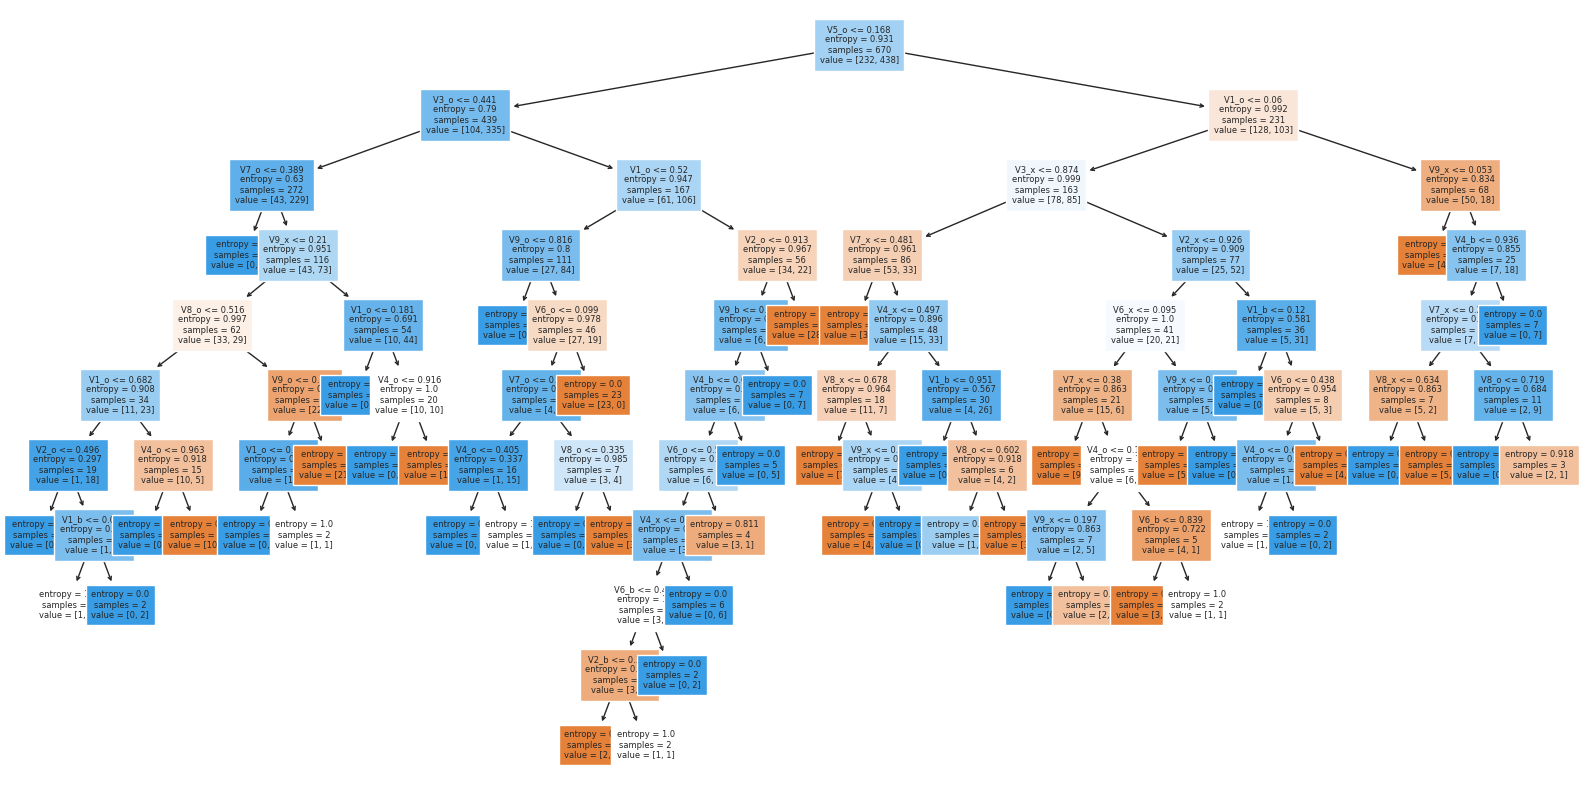

In [ ]:
tree_classifier = ptree.named_steps['tree']
ohe = ptree.named_steps['encoder']
feature_names = ohe.get_feature_names_out(X.columns)

plt.figure(figsize=(20,10))
plot_tree(tree_classifier, feature_names=feature_names, filled=True, fontsize=6)
plt.show()

In [ ]:
texto_modelo = export_text(
                    decision_tree = tree_classifier,
                    feature_names = feature_names
               )
print(texto_modelo)

|--- V5_o <= 0.17
|   |--- V3_o <= 0.44
|   |   |--- V7_o <= 0.39
|   |   |   |--- class: positive
|   |   |--- V7_o >  0.39
|   |   |   |--- V9_x <= 0.21
|   |   |   |   |--- V8_o <= 0.52
|   |   |   |   |   |--- V1_o <= 0.68
|   |   |   |   |   |   |--- V2_o <= 0.50
|   |   |   |   |   |   |   |--- class: positive
|   |   |   |   |   |   |--- V2_o >  0.50
|   |   |   |   |   |   |   |--- V1_b <= 0.09
|   |   |   |   |   |   |   |   |--- class: negative
|   |   |   |   |   |   |   |--- V1_b >  0.09
|   |   |   |   |   |   |   |   |--- class: positive
|   |   |   |   |   |--- V1_o >  0.68
|   |   |   |   |   |   |--- V4_o <= 0.96
|   |   |   |   |   |   |   |--- class: positive
|   |   |   |   |   |   |--- V4_o >  0.96
|   |   |   |   |   |   |   |--- class: negative
|   |   |   |   |--- V8_o >  0.52
|   |   |   |   |   |--- V9_o <= 0.37
|   |   |   |   |   |   |--- V1_o <= 0.81
|   |   |   |   |   |   |   |--- class: positive
|   |   |   |   |   |   |--- V1_o >  0.81
|   |   |   |   |

In [ ]:
print(tree_classifier.classes_)

['negative' 'positive']


**<span style="color:red">R3</span>**

In [ ]:
pd.to_pickle(ptree,'../02_Codes/01_Models/ptree.pkl')

In [ ]:
ptree = pd.read_pickle('../02_Codes/01_Models/ptree.pkl')

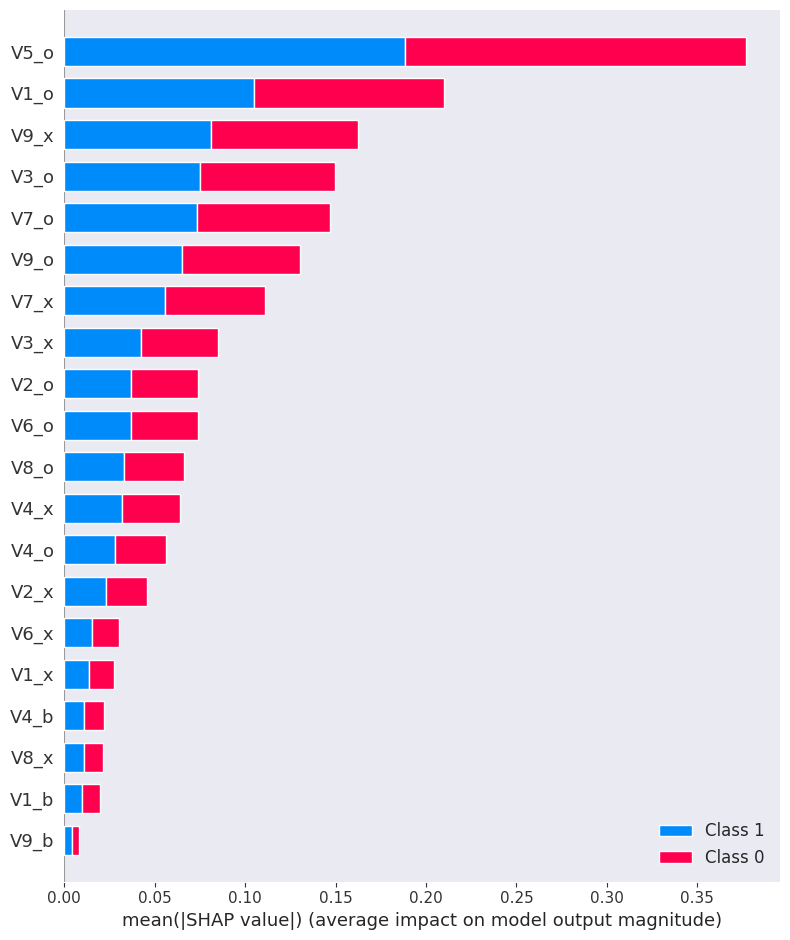

In [ ]:
X_train_encoded = ptree.named_steps['encoder'].transform(X_train)

explainer = shap.TreeExplainer(tree_classifier)
shap_values = explainer.shap_values(X_train_encoded)
shap.summary_plot(shap_values, X_train_encoded, feature_names=feature_names)


**<span style="color:red">R4</span>**

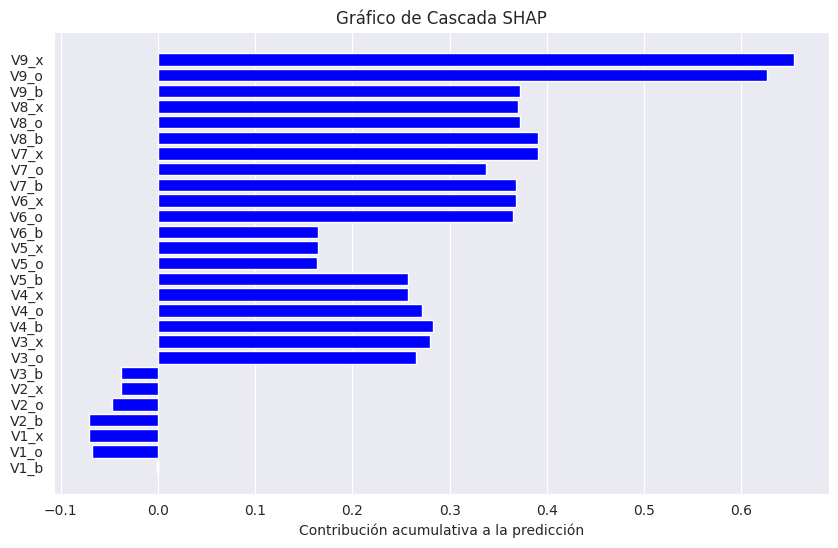

In [ ]:
sample_idx = 5
sample_shap_values = explainer.shap_values(X_train_encoded.iloc[sample_idx])
feature_names = X_train_encoded.columns
cumulative_contributions = np.cumsum(sample_shap_values[0])

plt.figure(figsize=(10, 6))
plt.barh(feature_names, cumulative_contributions, color='b')
plt.xlabel('Contribución acumulativa a la predicción')
plt.title('Gráfico de Cascada SHAP')
plt.grid(axis='x')
plt.show()
